In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zhonglifr/thyroid-disease-unsupervised-anomaly-detection")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 83.1k/83.1k [00:00<00:00, 586kB/s]

Extracting files...
Path to dataset files: C:\Users\naiks\.cache\kagglehub\datasets\zhonglifr\thyroid-disease-unsupervised-anomaly-detection\versions\2


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [37]:
df = pd.read_csv("annthyroid_unsupervised_anomaly_detection.csv", sep=";")


In [38]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label,Unnamed: 22,Unnamed: 23
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o,NaN,NaN
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o,NaN,NaN
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o,NaN,NaN
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o,NaN,NaN
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o,NaN,NaN


In [39]:
df.shape

(6916, 24)

In [40]:
print(df.isnull().sum())

Age                             0
Sex                             0
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
sick                            0
pregnant                        0
thyroid_surgery                 0
I131_treatment                  0
query_hypothyroid               0
query_hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH                             0
T3_measured                     0
TT4_measured                    0
T4U_measured                    0
FTI_measured                    0
Outlier_label                   0
Unnamed: 22                  6916
Unnamed: 23                  6916
dtype: int64


In [41]:
df = df.drop(columns=["Unnamed: 22", "Unnamed: 23"])

In [45]:
df.columns

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label '],
      dtype='object')

In [46]:
x = df.drop("Outlier_label ", axis = 1)
y = df["Outlier_label "]

In [47]:
x

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,61.00000,6.0000,23.0,87.0,26.0
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29.00000,15.0000,61.0,96.0,64.0
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,29.00000,19.0000,58.0,103.0,56.0
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,114.00000,3.0000,24.0,61.0,39.0
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,49.00000,3.0000,5.0,116.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00047,8.0000,154.0,75.0,204.0
6912,0.77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00006,0.0206,125.0,107.0,117.0
6913,0.41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00130,25.0000,125.0,114.0,109.0
6914,0.64,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00078,0.0206,106.0,88.0,121.0


In [48]:
y

0       o
1       o
2       o
3       o
4       o
       ..
6911    n
6912    n
6913    n
6914    n
6915    n
Name: Outlier_label , Length: 6916, dtype: object

In [49]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [50]:
x_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [69]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(n_estimators = 100,
                        contamination = 0.036,      # in our original dataset the exact outlier percent was 3.6 %   i.e = 250 outliers
                        random_state = 42)

In [70]:
labels = model.fit_predict(x_scaled)

In [71]:
labels    # 1 -> normal data points,  -1 -> outliers

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

### Using PCA for dim reducn for visualization

In [72]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components = 2)
x_pca = pca_model.fit_transform(x_scaled)

Text(0, 0.5, 'PC2')

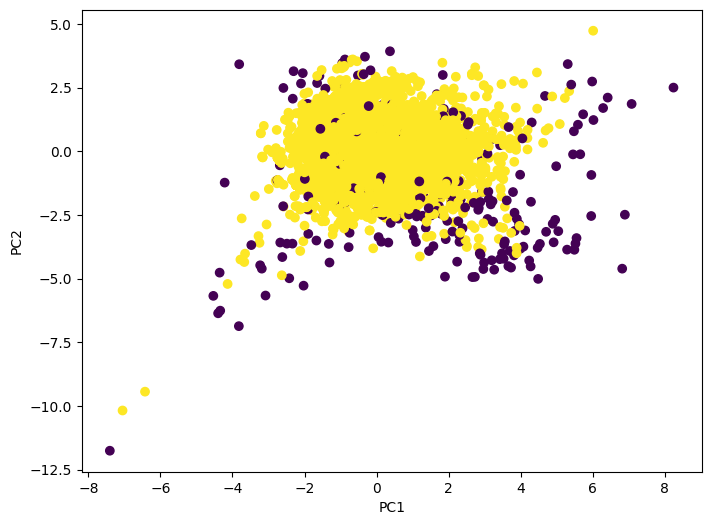

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(x_pca[:,0], x_pca[:,1], c = labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [74]:
# purple points -> outliers detected by our algo

In [75]:
import numpy as np

no_of_outliers = np.sum(labels == -1)
no_of_normals = np.sum(labels == 1)

print("outliers :",no_of_outliers)
print("normals :",no_of_normals)

outliers : 249
normals : 6667
